In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!cp /content/drive/MyDrive/CliniScan/CliniScan_images.zip /content/
!cp /content/drive/MyDrive/CliniScan/CliniScan_labels.zip /content/

In [8]:
!unzip -q CliniScan_images.zip
!unzip -q CliniScan_labels.zip

In [9]:
import os

print(os.listdir("/content"))

['.config', 'CliniScan_labels.zip', 'drive', 'CliniScan_images.zip', 'kaggle', 'sample_data']


In [10]:
!pip install ultralytics opencv-python pandas numpy matplotlib albumentations -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.3 MB/s eta 0:00:00


In [11]:
IMG_PATH = "/content/kaggle/working/CliniScan/images"
LABEL_PATH = "/content/kaggle/working/CliniScan/labels"

print("Total Images:", len(os.listdir(IMG_PATH)))
print("Total Labels:", len(os.listdir(LABEL_PATH)))

Total Images: 5000
Total Labels: 15000


In [12]:
import os

for file in os.listdir(LABEL_PATH):
    path = os.path.join(LABEL_PATH, file)
    if os.path.getsize(path) > 0:
        with open(path, "r") as f:
            print(f.read())
        break


3 1.30224609375 1.74951171875 1.0673828125 0.2646484375
3 1.3310546875 1.787109375 1.14453125 0.306640625
0 1.19677734375 1.15576171875 0.3525390625 0.3583984375
3 1.31103515625 1.7158203125 1.0830078125 0.333984375
0 1.18603515625 1.1396484375 0.3623046875 0.337890625
0 1.138671875 1.1396484375 0.498046875 0.423828125
7 1.24072265625 0.88037109375 0.3076171875 0.2470703125
7 0.7294921875 0.92578125 0.375 0.29296875



In [13]:
import cv2

bad_images = []

for img_file in os.listdir(IMG_PATH):
    img_path = os.path.join(IMG_PATH, img_file)
    img = cv2.imread(img_path)
    if img is None:
        bad_images.append(img_file)

print("Corrupted Images:", len(bad_images))

Corrupted Images: 0


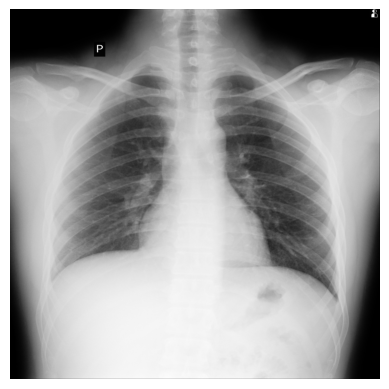

In [14]:
import random

sample_img = random.choice(os.listdir(IMG_PATH))
img_path = os.path.join(IMG_PATH, sample_img)
label_path = os.path.join(LABEL_PATH, sample_img.replace(".jpg", ".txt"))

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

if os.path.exists(label_path):
    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        class_id, x_center, y_center, width, height = map(float, line.split())

        x_center *= w
        y_center *= h
        width *= w
        height *= h

        x_min = int(x_center - width/2)
        y_min = int(y_center - height/2)
        x_max = int(x_center + width/2)
        y_max = int(y_center + height/2)

        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255,0,0), 2)

plt.imshow(img)
plt.axis("off")
plt.show()

In [15]:
import os
import random
import shutil

BASE_PATH = "/content/CliniScan"
os.makedirs(BASE_PATH + "/images/train", exist_ok=True)
os.makedirs(BASE_PATH + "/images/val", exist_ok=True)
os.makedirs(BASE_PATH + "/labels/train", exist_ok=True)
os.makedirs(BASE_PATH + "/labels/val", exist_ok=True)

images = os.listdir(IMG_PATH)
random.shuffle(images)

split = int(0.8 * len(images))

train_imgs = images[:split]
val_imgs = images[split:]

for img in train_imgs:
    shutil.move(os.path.join(IMG_PATH, img), BASE_PATH + "/images/train/" + img)
    shutil.move(os.path.join(LABEL_PATH, img.replace(".jpg", ".txt")), BASE_PATH + "/labels/train/" + img.replace(".jpg", ".txt"))

for img in val_imgs:
    shutil.move(os.path.join(IMG_PATH, img), BASE_PATH + "/images/val/" + img)
    shutil.move(os.path.join(LABEL_PATH, img.replace(".jpg", ".txt")), BASE_PATH + "/labels/val/" + img.replace(".jpg", ".txt"))

print("Dataset split complete.")

Dataset split complete.


In [16]:
class_names = [
    "Aortic enlargement",
    "Atelectasis",
    "Calcification",
    "Cardiomegaly",
    "Consolidation",
    "ILD",
    "Infiltration",
    "Lung Opacity",
    "Nodule/Mass",
    "Other lesion",
    "Pleural effusion",
    "Pleural thickening",
    "Pneumothorax",
    "Pulmonary fibrosis"
]

yaml_content = f"""
path: /content/CliniScan
train: images/train
val: images/val

names:
"""

for i, name in enumerate(class_names):
    yaml_content += f"  {i}: {name}\n"

with open("/content/CliniScan/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created.")

data.yaml created.
